# Hyperparameter Tuning Results Analysis

This notebook analyzes the results from the hyperparameter tuning experiments conducted in `hypr.py`. The results are stored in the `jax_hyperparameter_tuning2` directory.

The notebook performs the following steps:
1.  Loads the results from all experiment runs into a pandas DataFrame.
2.  Identifies the best performing hyperparameter configurations for both "Factorized" and "Joint" agents.
3.  Plots the performance (mean score) of the top agents against different noise levels.


In [10]:
# Imports and setup


In [11]:
import pandas as pd

# Load the aggregated results
df = pd.read_csv("aggregated_results.csv")

# Filter for noise levels between 0 and 0.25
df_filtered = df[(df['noise'] >= 0) & (df['noise'] <= 0.25)].copy()

# Exclude DBS for hyperparameter analysis
df_aif = df_filtered[df_filtered['agent_type'] != 'DBS'].copy()

# --- Analyze Factorized Agents ---
df_factorized = df_aif[df_aif['agent_type'] == 'Factorized'].copy()
param_cols = ['pB_scale', 'pB_lr', 'coop_bias', 'gamma', 'alpha', 'policy_len', 'update_interval', 'preferences', 'noisy_A']

# Calculate mean performance across the selected noise range
factorized_performance = df_factorized.groupby(param_cols)['mean_score'].mean().reset_index()

# Get the top 5 best performing hyperparameters
best_factorized_params = factorized_performance.sort_values('mean_score', ascending=False).head(5)

print("--- Top 5 Best Hyperparameters for Factorized Agents (Noise 0-0.25) ---")
display(best_factorized_params)


# --- Analyze Joint Agents ---
df_joint = df_aif[df_aif['agent_type'] == 'Joint'].copy()

# Calculate mean performance across the selected noise range
joint_performance = df_joint.groupby(param_cols)['mean_score'].mean().reset_index()

# Get the top 5 best performing hyperparameters
best_joint_params = joint_performance.sort_values('mean_score', ascending=False).head(5)

print("\n--- Top 5 Best Hyperparameters for Joint Agents (Noise 0-0.25) ---")
display(best_joint_params)


--- Top 5 Best Hyperparameters for Factorized Agents (Noise 0-0.25) ---


,pB_scale,pB_lr,coop_bias,gamma,alpha,policy_len,update_interval,preferences,noisy_A,mean_score
3,1.0,1.0,0.75,0.3,0.6,5.0,100.0,nash,False,1901.718750
9,100.0,1.0,0.25,0.6,0.3,1.0,10.0,standard,True,1854.991667
8,10.0,1.0,0.50,1.0,1.0,1.0,50.0,nash,True,1836.077083
5,1.0,1.5,0.50,0.3,0.3,5.0,50.0,nash,True,1835.706250
0,1.0,0.5,0.50,0.3,1.0,5.0,10.0,standard,False,1817.158333



--- Top 5 Best Hyperparameters for Joint Agents (Noise 0-0.25) ---


,pB_scale,pB_lr,coop_bias,gamma,alpha,policy_len,update_interval,preferences,noisy_A,mean_score
2,1.0,1.0,0.50,1.0,0.3,5.0,100.0,nash,False,1923.277083
6,10.0,0.5,0.75,1.0,0.3,10.0,50.0,nash,False,1909.752083
9,100.0,1.5,0.50,0.6,0.6,10.0,100.0,nash,False,1884.635417
8,100.0,1.0,0.50,1.0,0.3,5.0,10.0,nash,False,1881.654167
1,1.0,0.5,0.50,0.6,0.6,5.0,100.0,standard,True,1877.866667


In [12]:
import pandas as pd
import json
from pathlib import Path
import tqdm

root_dir = Path("jax_hyperparameter_tuning3")
data = []
dbs_data = []

experiment_dirs = [d for d in root_dir.iterdir() if d.is_dir()]

for experiment_dir in tqdm.tqdm(experiment_dirs):
    parts = experiment_dir.name.split('_')
    agent_type = parts[1]
    
    params = {}
    if agent_type == "FACTORIZED":
        params = {
            "agent_type": "Factorized",
            "pB_scale": float(parts[2]),
            "pB_lr": float(parts[3]),
            "coop_bias": float(parts[4]),
            "gamma": float(parts[5]),
            "alpha": float(parts[6]),
            "policy_len": int(parts[7]),
            "update_interval": int(parts[8]),
            "preferences": parts[9],
            "noisy_A": parts[10] == "True",
        }
    elif agent_type == "Joint":
        params = {
            "agent_type": "Joint",
            "pB_scale": float(parts[2]),
            "pB_lr": float(parts[3]),
            "coop_bias": float(parts[4]),
            "gamma": float(parts[5]),
            "alpha": float(parts[6]),
            "policy_len": int(parts[7]),
            "update_interval": int(parts[8]),
            "preferences": parts[9],
            "noisy_A": parts[10] == "True",
        }

    for repetition_dir in experiment_dir.glob("repetition_*"):
        repetition = int(repetition_dir.name.split('_')[1])
        
        details_file = repetition_dir / "details.json"
        if not details_file.exists():
            continue
        with open(details_file) as f:
            details = json.load(f)
            player_names = details["player_names"]
            aif_player_name_list = [p for p in player_names if "AIF" in p]
            dbs_player_name_list = [p for p in player_names if p.startswith("DBS")]

            if not aif_player_name_list or not dbs_player_name_list:
                continue
            
            aif_player_name = aif_player_name_list[0]
            dbs_player_name = dbs_player_name_list[0]

        for result_file in repetition_dir.glob("*.json"):
            if result_file.name == "details.json":
                continue
            
            noise_level = float(result_file.stem)
            
            with open(result_file) as f:
                stats = json.load(f)

            csv_file = result_file.with_suffix('.csv')
            if not csv_file.exists():
                continue
            
            # Calculate ranks from CSV
            csv_df = pd.read_csv(csv_file)
            ranks = csv_df.groupby('Player name')['Score'].mean().rank(ascending=False, method='min').astype(int).to_dict()

            if aif_player_name in stats:
                player_stats = stats[aif_player_name]
                entry = params.copy()
                entry.update({
                    "repetition": repetition,
                    "noise": noise_level,
                    "mean_score": player_stats["mean_score"],
                    "cooperation_rate": player_stats["cooperation_rate"],
                    "rank": ranks.get(aif_player_name),
                })
                data.append(entry)

            if dbs_player_name in stats:
                player_stats = stats[dbs_player_name]
                dbs_entry = {
                    "repetition": repetition,
                    "noise": noise_level,
                    "mean_score": player_stats["mean_score"],
                    "cooperation_rate": player_stats["cooperation_rate"],
                    "rank": ranks.get(dbs_player_name),
                }
                dbs_data.append(dbs_entry)

df = pd.DataFrame(data)
dbs_df = pd.DataFrame(dbs_data)

print("AIF Data:")
display(df.head())
print("\nDBS Data:")
display(dbs_df.head())


100%|██████████| 70/70 [00:09<00:00,  7.16it/s]

AIF Data:


,agent_type,pB_scale,pB_lr,coop_bias,gamma,alpha,policy_len,update_interval,preferences,noisy_A,repetition,noise,mean_score,cooperation_rate,rank
0,Factorized,1.0,1.0,0.75,0.6,1.0,10,10,standard,True,0,0.05,1611.80,0.361667,18
1,Factorized,1.0,1.0,0.75,0.6,1.0,10,10,standard,True,0,0.45,2219.10,0.484056,9
2,Factorized,1.0,1.0,0.75,0.6,1.0,10,10,standard,True,0,0.25,1975.70,0.415722,16
3,Factorized,1.0,1.0,0.75,0.6,1.0,10,10,standard,True,0,0.00,1485.05,0.343167,18
4,Factorized,1.0,1.0,0.75,0.6,1.0,10,10,standard,True,0,0.30,2093.35,0.431000,12



DBS Data:


,repetition,noise,mean_score,cooperation_rate,rank
0,0,0.05,2101.00,0.399056,2
1,0,0.45,2220.80,0.480444,8
2,0,0.25,2100.65,0.451444,2
3,0,0.00,2352.55,0.474167,9
4,0,0.30,2124.85,0.455333,4


Top 3 best parameters for Factorized Agent per noise level:

--- Noise Level: 0.0 ---
     pB_scale  pB_lr  coop_bias  gamma  alpha  policy_len  update_interval  \
76        1.0    1.5       0.50    1.0    0.6          10               10   
94       10.0    0.5       0.50    1.0    0.6          10              100   
118      10.0    0.5       0.75    1.0    0.3          10               50   

    preferences  noisy_A  mean_score  
76         nash    False   2028.8500  
94         nash    False   1973.6125  
118        nash    False   1936.5500  

--- Noise Level: 0.05 ---
    pB_scale  pB_lr  coop_bias  gamma  alpha  policy_len  update_interval  \
42       1.0    1.0        0.5    1.0    0.3           5              100   
95      10.0    0.5        0.5    1.0    0.6          10              100   
77       1.0    1.5        0.5    1.0    0.6          10               10   

   preferences  noisy_A  mean_score  
42        nash    False     1942.95  
95        nash    False     1930.

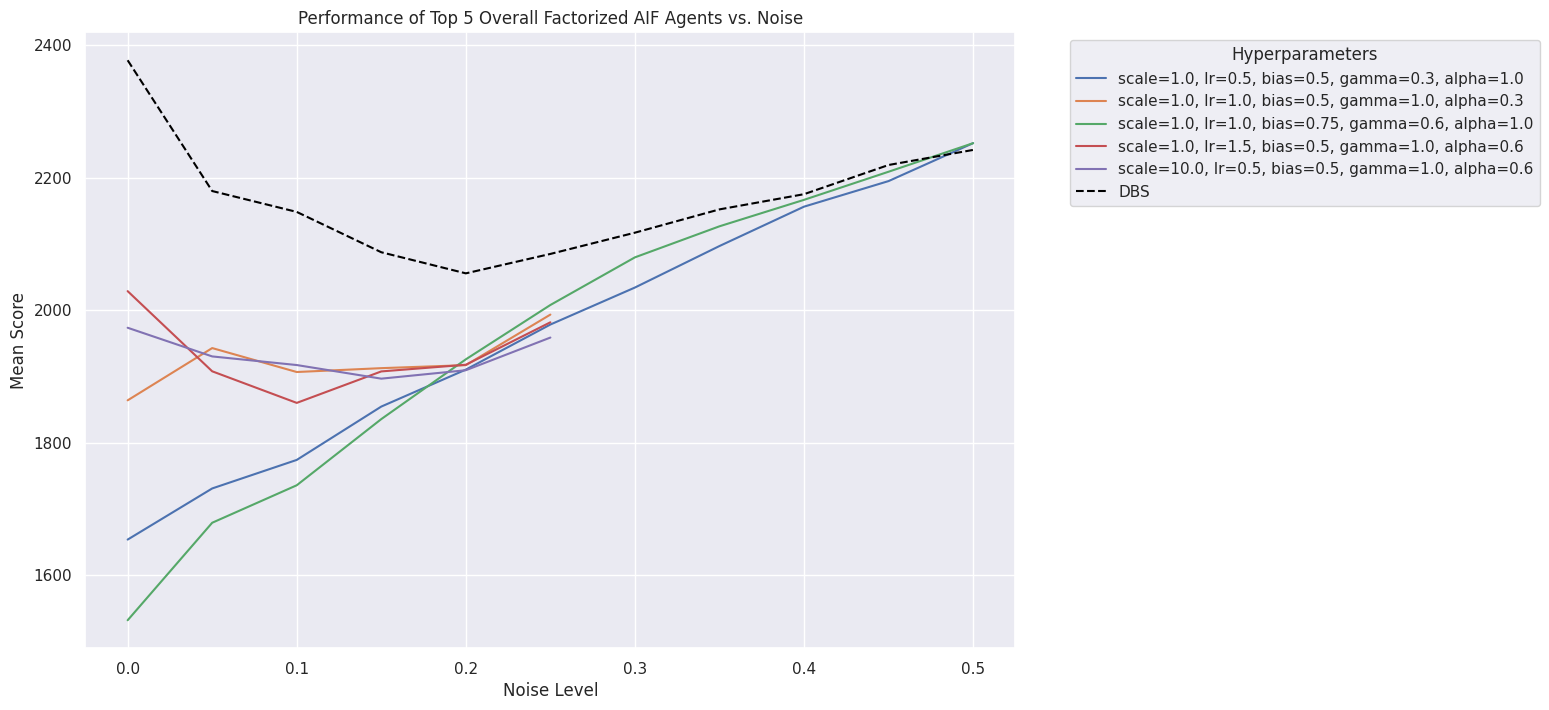

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Analyze Factorized Agents
df_factorized = df[df['agent_type'] == 'Factorized'].copy()

# Group by parameters and calculate mean score across all noise levels (for plotting)
param_cols = ['pB_scale', 'pB_lr', 'coop_bias', 'gamma', 'alpha', 'policy_len', 'update_interval', 'preferences', 'noisy_A']
performance = df_factorized.groupby(param_cols)['mean_score'].mean().reset_index()

# Sort to find best parameters overall (for plotting)
best_params_for_plot = performance.sort_values('mean_score', ascending=False).head(5)


# Calculate mean scores per parameter set *and* noise level, averaging over repetitions
df_agg = df_factorized.groupby(param_cols + ['noise'])['mean_score'].mean().reset_index()

print("Top 3 best parameters for Factorized Agent per noise level:")
for noise_level in sorted(df_agg['noise'].unique()):
    print(f"\n--- Noise Level: {noise_level} ---")
    top_for_noise = df_agg[df_agg['noise'] == noise_level].sort_values('mean_score', ascending=False).head(3)
    print(top_for_noise[param_cols + ['mean_score']])


# Plotting (uses the overall best params)
plt.figure(figsize=(12, 8))

# Get the data for the best parameter sets
best_param_list = [tuple(row) for row in best_params_for_plot[param_cols].to_numpy()]
df_best = df_factorized[df_factorized[param_cols].apply(tuple, axis=1).isin(best_param_list)]

# Aggregate over repetitions
df_plot = df_best.groupby(param_cols + ['noise'])['mean_score'].mean().reset_index()

# Create a nice legend label
def create_label(row):
    return f"scale={row['pB_scale']}, lr={row['pB_lr']}, bias={row['coop_bias']}, gamma={row['gamma']}, alpha={row['alpha']}"

df_plot['label'] = df_plot.apply(create_label, axis=1)

sns.lineplot(data=df_plot, x='noise', y='mean_score', hue='label')

# Plot DBS performance
dbs_plot_df = dbs_df.groupby('noise')['mean_score'].mean().reset_index()
sns.lineplot(data=dbs_plot_df, x='noise', y='mean_score', label='DBS', linestyle='--', color='black')


plt.title('Performance of Top 5 Overall Factorized AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Mean Score')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



Top 3 best parameters for Joint Agent per noise level:

--- Noise Level: 0.0 ---
     pB_scale  pB_lr  coop_bias  gamma  alpha  policy_len  update_interval  \
30        1.0    1.0       0.25    1.0    1.0          10               50   
150      10.0    1.0       0.75    1.0    0.6           5               10   
162      10.0    1.5       0.75    1.0    1.0          10               10   

    preferences  noisy_A  mean_score  
30         nash    False   2046.2875  
150        nash    False   2028.0125  
162    standard     True   2004.7125  

--- Noise Level: 0.05 ---
     pB_scale  pB_lr  coop_bias  gamma  alpha  policy_len  update_interval  \
31        1.0    1.0       0.25    1.0    1.0          10               50   
151      10.0    1.0       0.75    1.0    0.6           5               10   
163      10.0    1.5       0.75    1.0    1.0          10               10   

    preferences  noisy_A  mean_score  
31         nash    False   1982.5375  
151        nash    False   1917

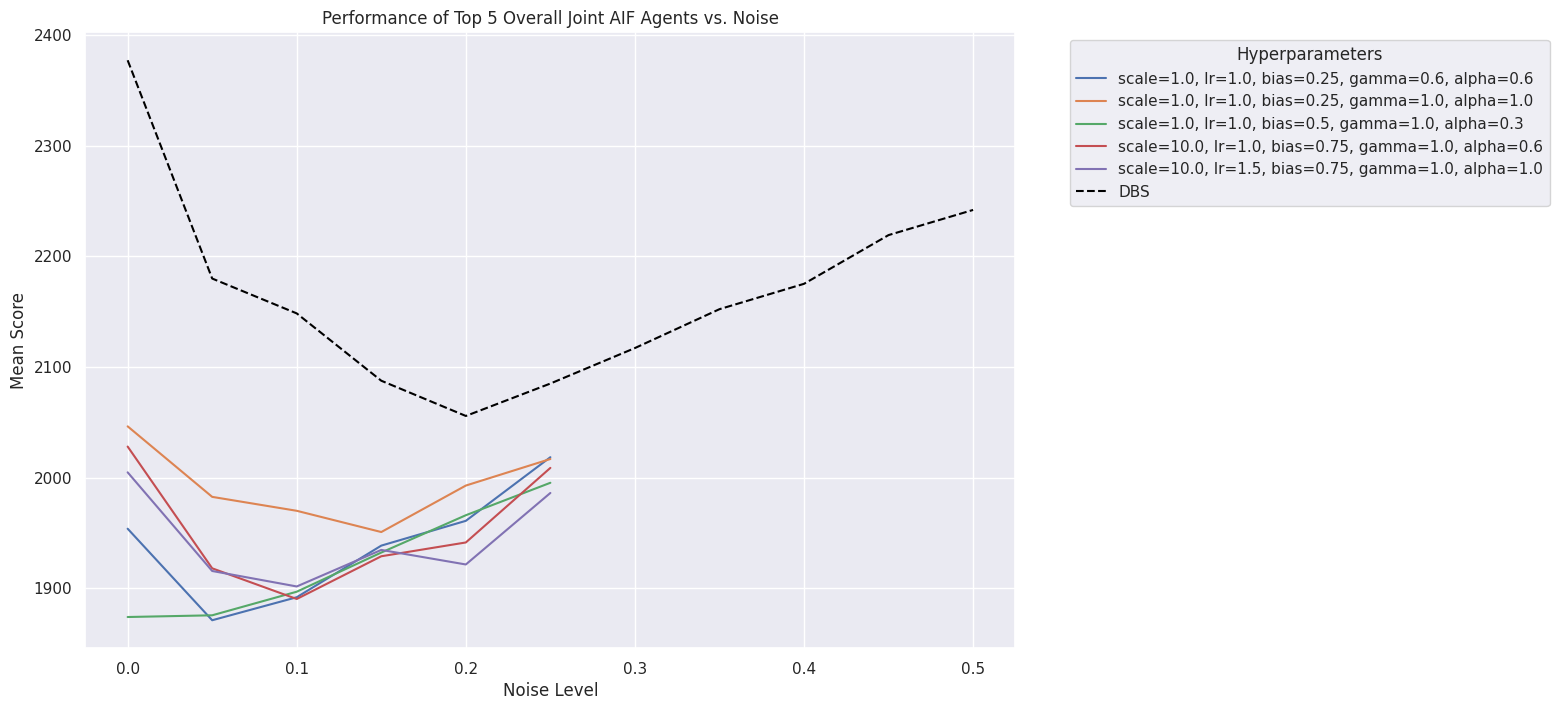

In [14]:
# Analyze Joint Agents
df_joint = df[df['agent_type'] == 'Joint'].copy()

# Group by parameters and calculate mean score across all noise levels (for plotting)
performance_joint = df_joint.groupby(param_cols)['mean_score'].mean().reset_index()

# Sort to find best parameters overall (for plotting)
best_params_joint_for_plot = performance_joint.sort_values('mean_score', ascending=False).head(5)

# Calculate mean scores per parameter set *and* noise level, averaging over repetitions
df_agg_joint = df_joint.groupby(param_cols + ['noise'])['mean_score'].mean().reset_index()

print("\nTop 3 best parameters for Joint Agent per noise level:")
for noise_level in sorted(df_agg_joint['noise'].unique()):
    print(f"\n--- Noise Level: {noise_level} ---")
    top_for_noise = df_agg_joint[df_agg_joint['noise'] == noise_level].sort_values('mean_score', ascending=False).head(3)
    print(top_for_noise[param_cols + ['mean_score']])


# Plotting
plt.figure(figsize=(12, 8))

# Get the data for the best parameter sets
best_param_list_joint = [tuple(row) for row in best_params_joint_for_plot[param_cols].to_numpy()]
df_best_joint = df_joint[df_joint[param_cols].apply(tuple, axis=1).isin(best_param_list_joint)]

# Aggregate over repetitions
df_plot_joint = df_best_joint.groupby(param_cols + ['noise'])['mean_score'].mean().reset_index()

# Create a nice legend label
df_plot_joint['label'] = df_plot_joint.apply(create_label, axis=1)

sns.lineplot(data=df_plot_joint, x='noise', y='mean_score', hue='label')

# Plot DBS performance
dbs_plot_df = dbs_df.groupby('noise')['mean_score'].mean().reset_index()
sns.lineplot(data=dbs_plot_df, x='noise', y='mean_score', label='DBS', linestyle='--', color='black')

plt.title('Performance of Top 5 Overall Joint AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Mean Score')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


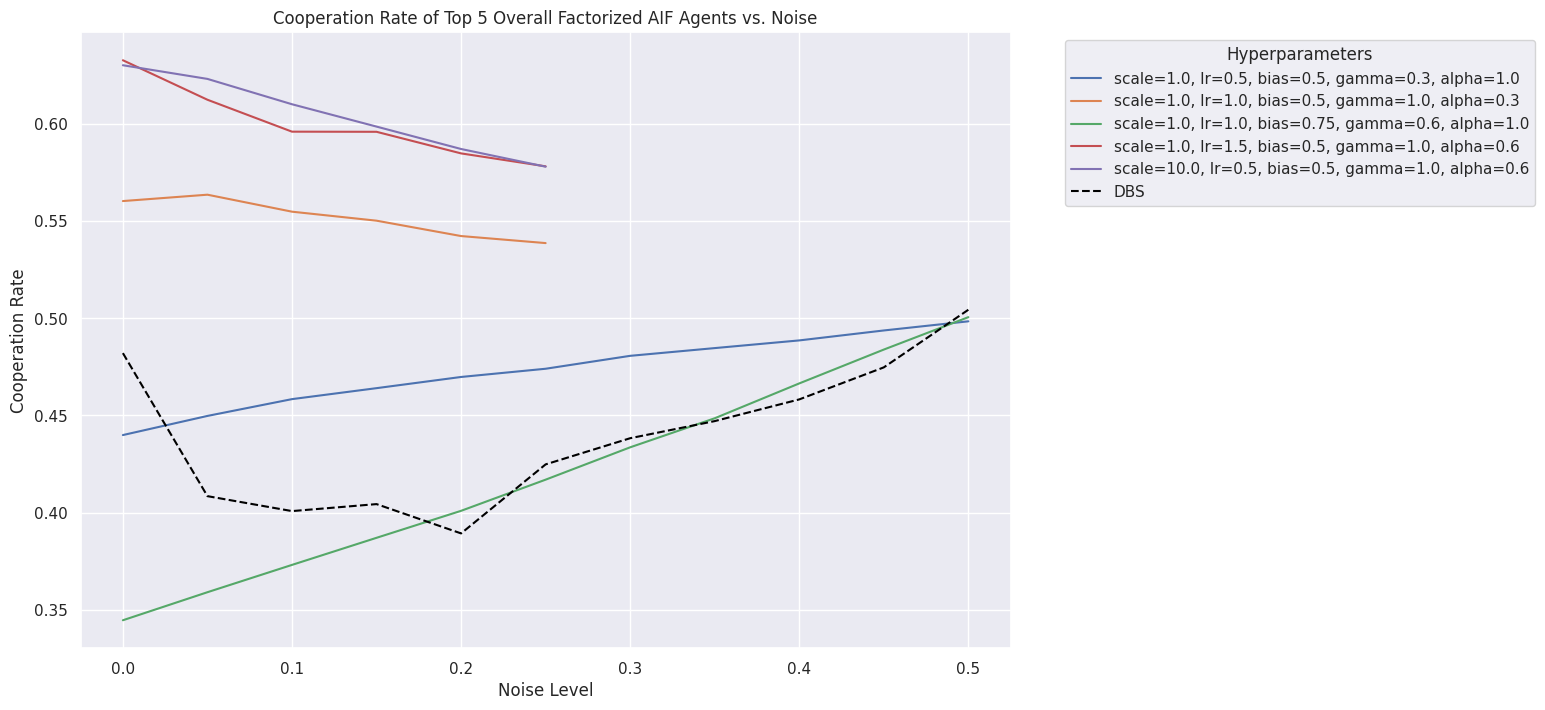

In [15]:
# Plotting Cooperation Rates for Factorized Agents
plt.figure(figsize=(12, 8))

# Aggregate cooperation rates over repetitions for the best agents
df_plot_coop = df_best.groupby(param_cols + ['noise'])['cooperation_rate'].mean().reset_index()
df_plot_coop['label'] = df_plot_coop.apply(create_label, axis=1)

sns.lineplot(data=df_plot_coop, x='noise', y='cooperation_rate', hue='label')

# Plot DBS cooperation rate
dbs_plot_coop_df = dbs_df.groupby('noise')['cooperation_rate'].mean().reset_index()
sns.lineplot(data=dbs_plot_coop_df, x='noise', y='cooperation_rate', label='DBS', linestyle='--', color='black')

plt.title('Cooperation Rate of Top 5 Overall Factorized AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Cooperation Rate')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


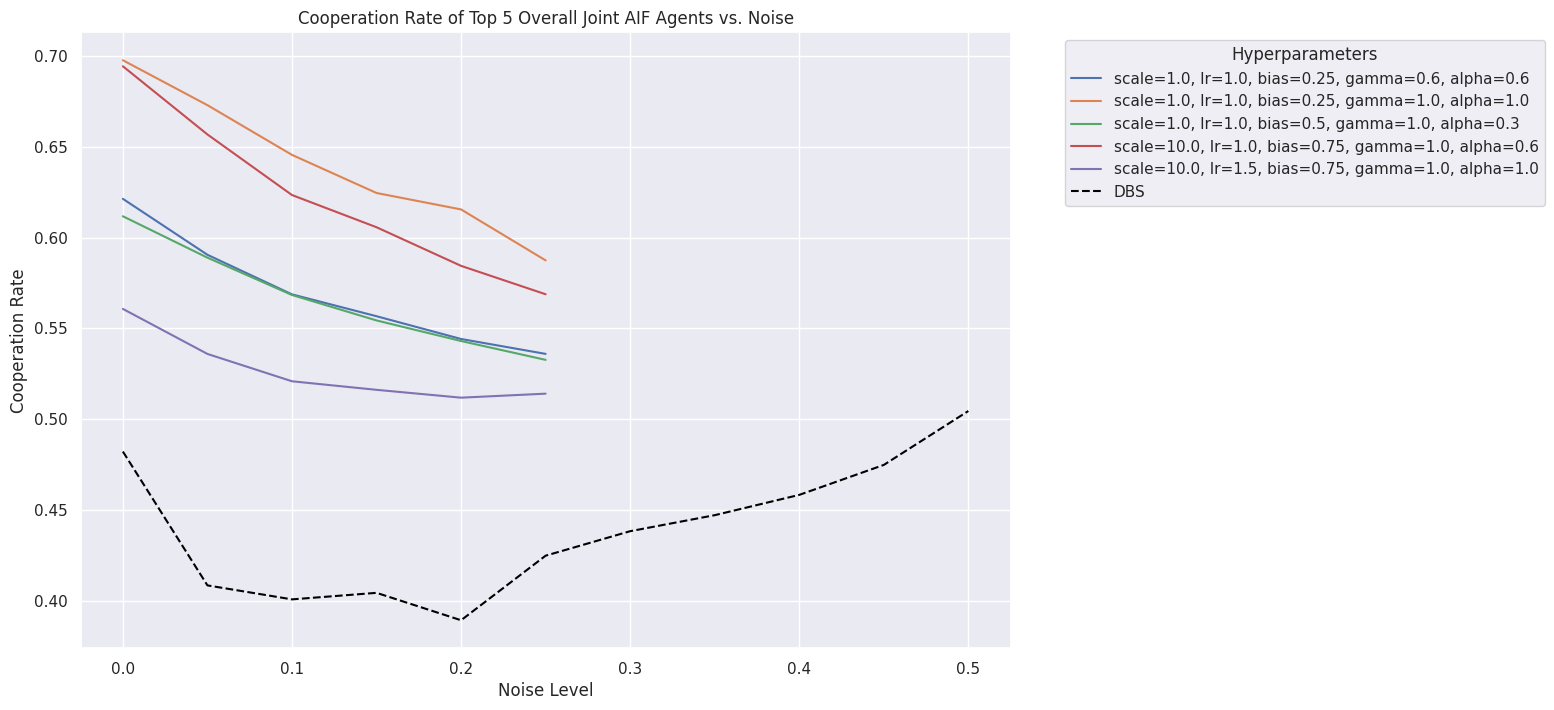

In [16]:
# Plotting Cooperation Rates for Joint Agents
plt.figure(figsize=(12, 8))

# Aggregate cooperation rates over repetitions for the best agents
df_plot_joint_coop = df_best_joint.groupby(param_cols + ['noise'])['cooperation_rate'].mean().reset_index()
df_plot_joint_coop['label'] = df_plot_joint_coop.apply(create_label, axis=1)

sns.lineplot(data=df_plot_joint_coop, x='noise', y='cooperation_rate', hue='label')

# Plot DBS cooperation rate
dbs_plot_coop_df = dbs_df.groupby('noise')['cooperation_rate'].mean().reset_index()
sns.lineplot(data=dbs_plot_coop_df, x='noise', y='cooperation_rate', label='DBS', linestyle='--', color='black')

plt.title('Cooperation Rate of Top 5 Overall Joint AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Cooperation Rate')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


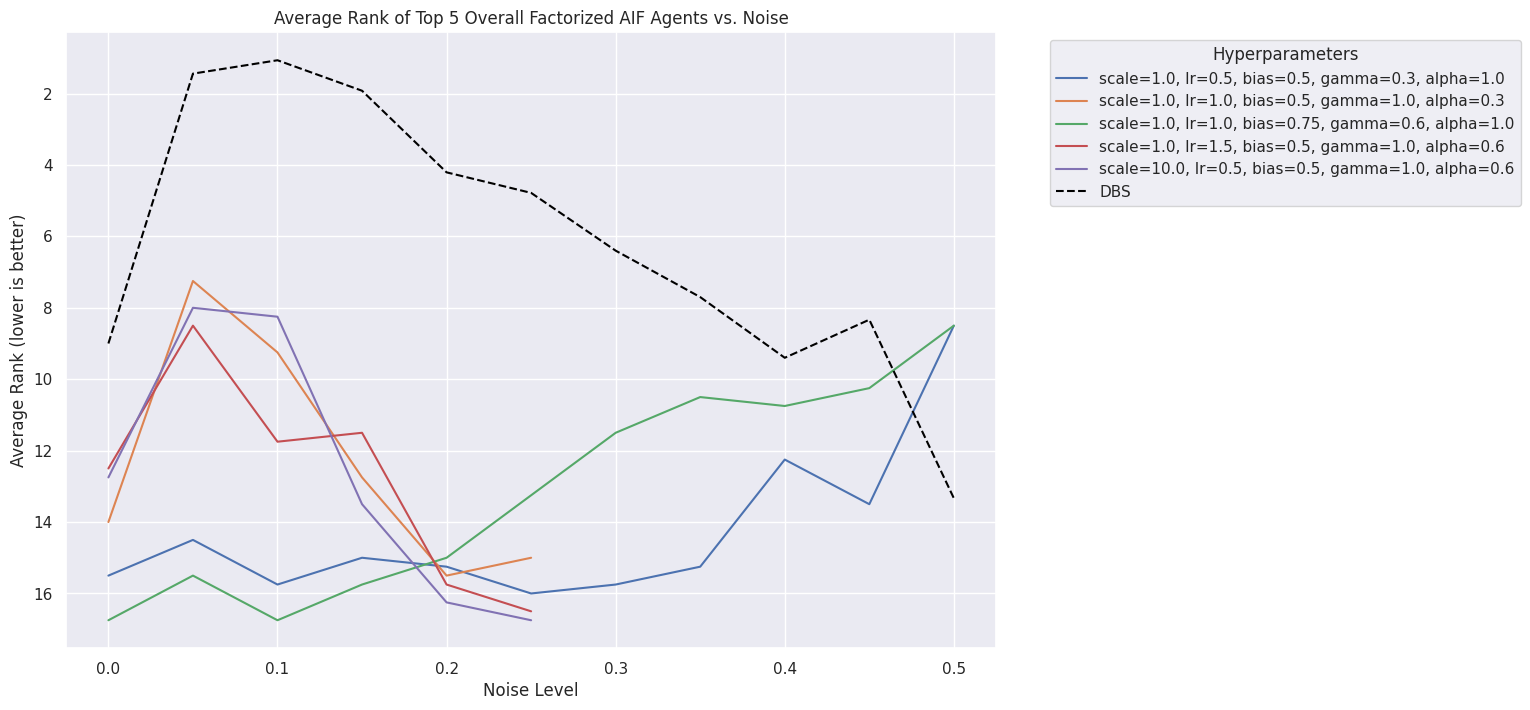

In [17]:
# Plotting Rank for Factorized Agents
plt.figure(figsize=(12, 8))

# Aggregate rank over repetitions for the best agents
df_plot_rank = df_best.groupby(param_cols + ['noise'])['rank'].mean().reset_index()
df_plot_rank['label'] = df_plot_rank.apply(create_label, axis=1)

sns.lineplot(data=df_plot_rank, x='noise', y='rank', hue='label')

# Plot DBS rank
dbs_plot_rank_df = dbs_df.groupby('noise')['rank'].mean().reset_index()
sns.lineplot(data=dbs_plot_rank_df, x='noise', y='rank', label='DBS', linestyle='--', color='black')

plt.title('Average Rank of Top 5 Overall Factorized AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Average Rank (lower is better)')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()


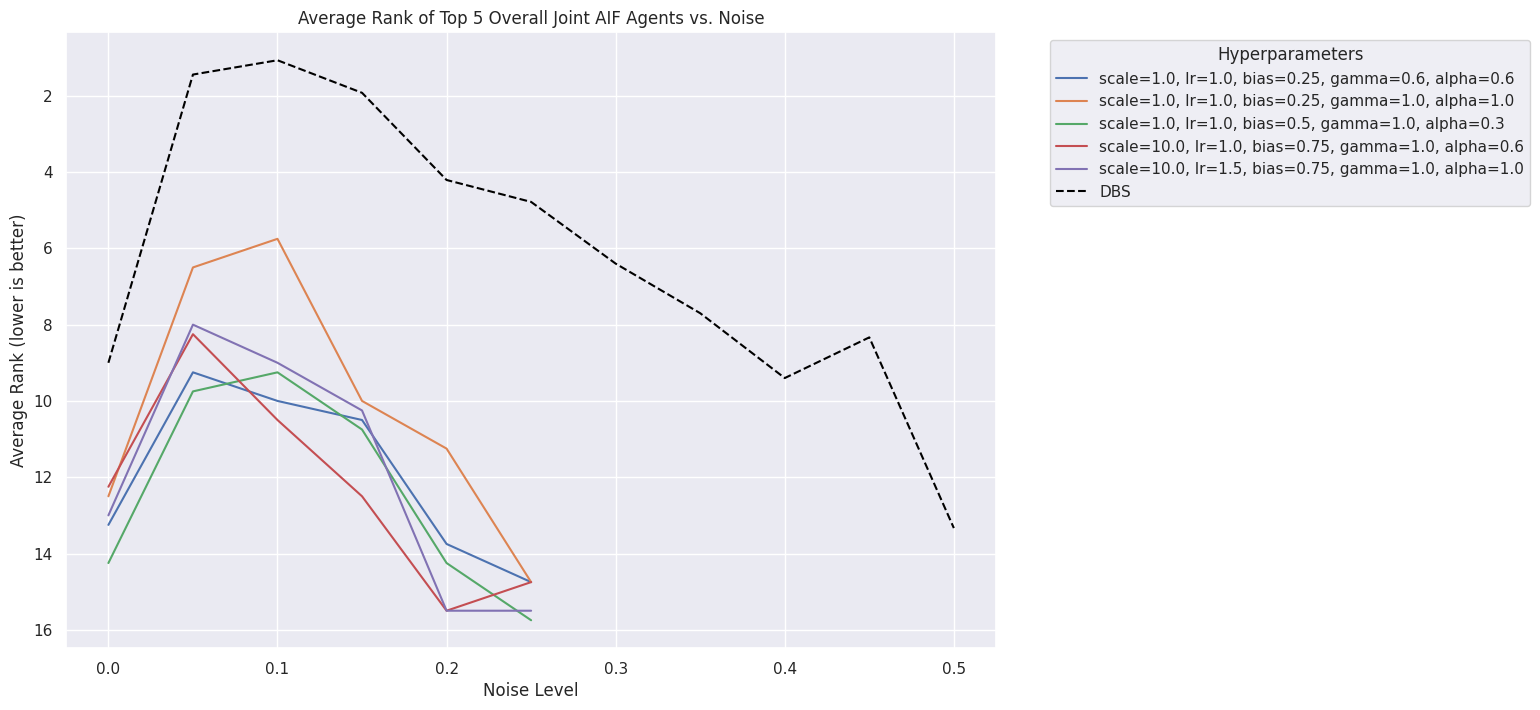

In [18]:
# Plotting Rank for Joint Agents
plt.figure(figsize=(12, 8))

# Aggregate rank over repetitions for the best agents
df_plot_joint_rank = df_best_joint.groupby(param_cols + ['noise'])['rank'].mean().reset_index()
df_plot_joint_rank['label'] = df_plot_joint_rank.apply(create_label, axis=1)

sns.lineplot(data=df_plot_joint_rank, x='noise', y='rank', hue='label')

# Plot DBS rank
dbs_plot_rank_df = dbs_df.groupby('noise')['rank'].mean().reset_index()
sns.lineplot(data=dbs_plot_rank_df, x='noise', y='rank', label='DBS', linestyle='--', color='black')

plt.title('Average Rank of Top 5 Overall Joint AIF Agents vs. Noise')
plt.xlabel('Noise Level')
plt.ylabel('Average Rank (lower is better)')
plt.legend(title='Hyperparameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()


In [19]:
# --- Create a single DataFrame with all results and save to CSV ---

# Prepare DBS data for concatenation
dbs_summary_df = dbs_df.copy()
dbs_summary_df['agent_type'] = 'DBS'
print(dbs_summary_df.head())
# Fill param_cols with a placeholder for grouping
for col in param_cols:
    dbs_summary_df[col] = "N/A"

# Combine AIF and DBS data
all_data_df = pd.concat([df, dbs_summary_df], ignore_index=True)

# Define columns to group by
grouping_cols = ['agent_type', 'noise'] + param_cols

# Aggregate data over repetitions
final_df = all_data_df.groupby(grouping_cols).agg(
    mean_score=('mean_score', 'mean'),
    mean_cooperation_rate=('cooperation_rate', 'mean'),
    mean_rank=('rank', 'mean')
).reset_index()


# Display the final DataFrame
print("Aggregated Results DataFrame (including DBS):")
display(final_df.tail(15)) # Show tail to confirm DBS is present

# Save to CSV
output_path = "aggregated_results.csv"
final_df.to_csv(output_path, index=False)
print(f"\nSaved aggregated results to '{output_path}'")


   repetition  noise  mean_score  cooperation_rate  rank agent_type
0           0   0.05     2101.00          0.399056     2        DBS
1           0   0.45     2220.80          0.480444     8        DBS
2           0   0.25     2100.65          0.451444     2        DBS
3           0   0.00     2352.55          0.474167     9        DBS
4           0   0.30     2124.85          0.455333     4        DBS
Aggregated Results DataFrame (including DBS):


,agent_type,noise,pB_scale,pB_lr,coop_bias,gamma,alpha,policy_len,update_interval,preferences,noisy_A,mean_score,mean_cooperation_rate,mean_rank
431,Joint,0.25,10.0,1.0,0.75,1.0,0.6,5,10,nash,False,2008.7375,0.568764,14.75
432,Joint,0.25,10.0,1.5,0.75,0.6,0.3,5,50,nash,False,1993.1375,0.522944,15.50
433,Joint,0.25,10.0,1.5,0.75,1.0,1.0,10,10,standard,True,1986.0750,0.514028,15.50
434,Joint,0.25,100.0,0.5,0.25,0.3,0.6,5,10,standard,False,2000.5625,0.457500,14.25
435,Joint,0.25,100.0,0.5,0.25,0.3,1.0,5,100,standard,False,1992.5375,0.431028,15.00
436,Joint,0.25,100.0,0.5,0.25,0.6,0.6,1,10,standard,False,1998.3625,0.414167,15.25
437,Joint,0.25,100.0,0.5,0.25,1.0,0.3,5,50,standard,False,1989.6875,0.433083,15.25
438,Joint,0.25,100.0,0.5,0.5,0.3,0.6,1,100,standard,False,1998.2250,0.478389,14.75
439,Joint,0.25,100.0,0.5,0.5,0.3,0.6,10,100,nash,False,2002.8750,0.522139,14.75
440,Joint,0.25,100.0,0.5,0.5,0.3,0.6,10,100,standard,True,1976.2625,0.487792,16.00



Saved aggregated results to 'aggregated_results.csv'
